In [14]:
import json
import os
import subprocess
import time
from typing import Optional
from common import *
from experiment import NetworkSetting
from data.media import MediaExperiment
from treatments.media import treatment_map

# Collect Data

In [11]:
labels = [
    'baseline',
    'psum_delay0',
    'psum_delay45',
    # 'psum_delay90',
    # 'psum_delay45_hint',
    # 'psum_delay45_nack',
    # 'psum_delay45_hint_nack',
    # 'iblt_delay0',
    # 'iblt_delay45',
    # 'iblt_delay90',
    # 'iblt_delay45_hint',
    # 'iblt_delay45_nack',
    # 'iblt_delay45_hint_nack'
]
TREATMENTS = [treatment_map[label] for label in labels]
NETWORK_SETTING = lambda loss1: NetworkSetting(bw1=100, bw2=10, delay1=1, delay2=25, loss1=str(loss1), loss2=0)
DURATION = 180

In [12]:
# data packet every 20 ms
exp = MediaExperiment(DURATION, TREATMENTS, NETWORK_SETTING(4))
data = exp.to_raw_data(execute=True)
results = data.data

1
sudo -E python3 emulation/main.py --loss1 4 --loss2 0 --label psum_delay0 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 0 --duration 180 181.6105077266693


In [4]:
# check results
def check_media_output(output):
    assert isinstance(output.get('client_latencies'), list)
    assert len(output['client_latencies']) > 0
    assert isinstance(output.get('server_latencies'), list)
    assert len(output['server_latencies']) > 0
    assert isinstance(output.get('client_num_spurious'), int)

for label in labels:
    print(label)
    check_media_output(results[label])

baseline
psum_delay45


# Plot CDF Data

In [5]:
def preprocess_latencies(latencies, num_ticks=100):
    ticks = []
    latencies.sort()
    for i in range(num_ticks):
        index = int(i * len(latencies) / num_ticks)
        ticks.append(latencies[index])
    ticks.append(latencies[-1])
    # Convert ns to ms
    return [tick / 1000000.0 for tick in ticks]

In [15]:
def plot_delay_cdf(labels, results, title, min_pct=0, num_ticks=1000, pdf: Optional[str]=None):
    plt.figure(figsize=(6, 4))
    for label in labels:
        data = results[label]
        data = preprocess_latencies(data, num_ticks=num_ticks)
        ys = [i / len(data) * 100.0 for i in range(len(data))]
        plt.plot(data, ys, label=label)
    plt.xlabel('De-Jitter Latency (ms)')
    plt.xticks()
    plt.xlim(0)

    plt.ylabel('Percentile')
    ticks = [tick for tick in range(min_pct, num_ticks + 1, 2)]
    plt.yticks(ticks=ticks, labels=[f'{tick}%' for tick in ticks])
    plt.yticks()
    plt.ylim(min_pct, 100.5)

    plt.grid()
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3)
    if pdf:
        save_pdf(pdf)
    plt.show()

../figures/media_benchmark.pdf


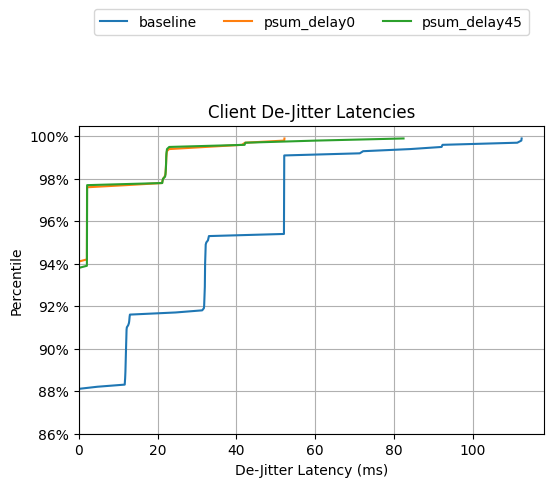

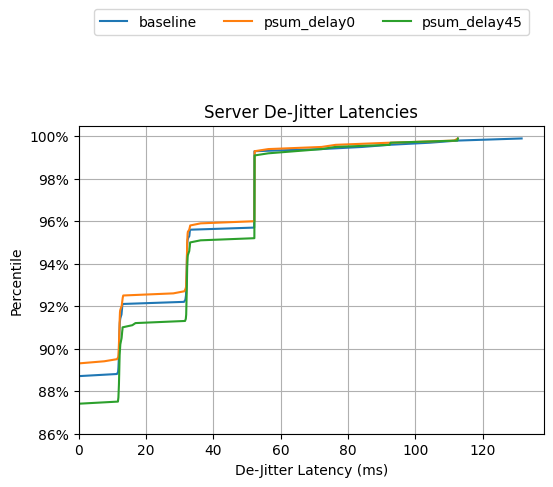

In [16]:
client_results = {}
server_results = {}
for label, result in results.items():
    client_results[label] = result.get('client_latencies')
    server_results[label] = result.get('server_latencies')
plot_delay_cdf(labels, client_results, min_pct=86, title='Client De-Jitter Latencies', pdf='../figures/media_benchmark.pdf')
plot_delay_cdf(labels, server_results, min_pct=86, title='Server De-Jitter Latencies')

# Plot network statistics

In [11]:
def plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets'):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        ifaces = results[label]['statistics']['ifaces']
        data = results[label]['statistics'][statistic]
        assert len(data) == len(ifaces)
        x = np.arange(len(ifaces))
        plt.bar(x + i * width, data, width=width, label=label)

    plt.xlabel('Network Interface')
    plt.ylabel(statistic)
    plt.xticks(np.arange(len(ifaces)), ifaces)
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3)
    plt.show()

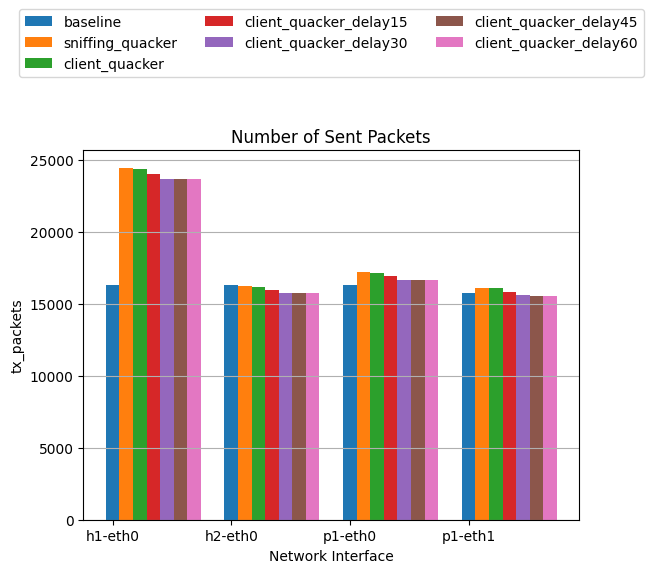

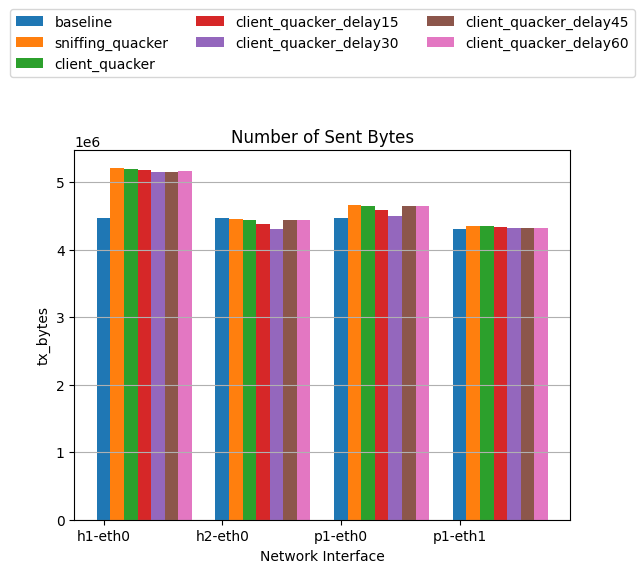

In [12]:
plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets')
plot_network_statistic(labels, results, title='Number of Sent Bytes', statistic='tx_bytes')

# Plot num spurious

In [13]:
def plot_num_spurious(labels, results, title='Number Spurious Received'):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        num_spurious = results[label]['client_num_spurious']
        plt.bar([i * width], num_spurious, width=width, label=label)

    plt.ylabel('Num Spurious Received')
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
    plt.show()

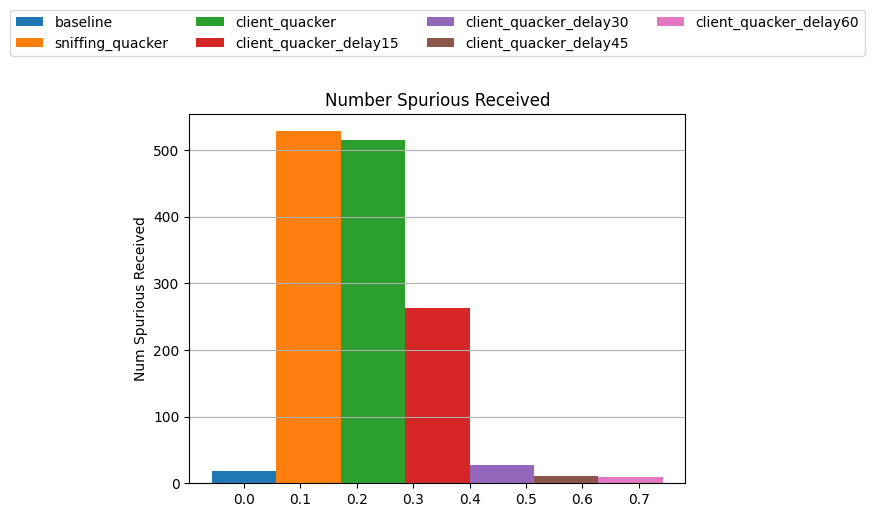

In [14]:
plot_num_spurious(labels, results)